In [2]:
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG19, ResNet50, DenseNet121, Xception, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, \
                            precision_score, recall_score, accuracy_score, roc_curve

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Paths
os.chdir('/Users/badisasaisriharsha/Desktop/Glaucoma-Detection-ResCapsNet')
TRAIN_DIR   = 'data/processed/combined/Train'
VAL_DIR     = 'data/processed/combined/Validation'
MODEL_DIR   = 'models';           os.makedirs(MODEL_DIR, exist_ok=True)
RESULTS_DIR = 'results/predictions'; os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs('results/plots', exist_ok=True)

# Config
IMG_SIZE     = 256
BATCH_SIZE   = 32
EPOCHS_A     = 15
EPOCHS_B     = 15
FOCAL_ALPHA  = 0.5649
FOCAL_GAMMA  = 2.0

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Train dir exists:", os.path.isdir(TRAIN_DIR))
print("Val dir exists:  ", os.path.isdir(VAL_DIR))

TF: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train dir exists: True
Val dir exists:   True


In [3]:
# Cell 2 — Focal Loss
def focal_loss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss_fn

print("Focal loss defined. alpha=", FOCAL_ALPHA, "gamma=", FOCAL_GAMMA)

Focal loss defined. alpha= 0.5649 gamma= 2.0


In [4]:
# Cell 3 — Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', seed=SEED, shuffle=False
)

print("Train samples:", train_gen.samples)
print("Val samples:  ", val_gen.samples)
print("Class indices:", train_gen.class_indices)

Found 1163 images belonging to 2 classes.
Found 293 images belonging to 2 classes.
Train samples: 1163
Val samples:   293
Class indices: {'Glaucoma_Negative': 0, 'Glaucoma_Positive': 1}


In [5]:
# Cell 4 — Model builder, callbacks, scoring utilities

def build_model(base_fn, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base.input, outputs=out)
    return model, base

def get_callbacks(model_name):
    return [
        ReduceLROnPlateau(monitor='val_auc', patience=3, factor=0.3,
                          min_lr=1e-7, mode='max', verbose=1),
        EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True,
                      mode='max', verbose=1),
        ModelCheckpoint(f'{MODEL_DIR}/{model_name}_best.h5', monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0)
    ]

def unfreeze_top_25pct(base):
    n = len(base.layers)
    cutoff = int(n * 0.75)
    for layer in base.layers[:cutoff]:
        layer.trainable = False
    for layer in base.layers[cutoff:]:
        layer.trainable = True
    print(f"  Unfroze last {n - cutoff} of {n} layers ({(n-cutoff)/n*100:.1f}%)")

def save_predictions(model, gen, model_name):
    gen.reset()
    probs = model.predict(gen, verbose=0).flatten()
    df = pd.DataFrame({
        'image_id':   [os.path.basename(f) for f in gen.filenames],
        'true_label': gen.classes,
        'pred_prob':  probs
    })
    df.to_csv(f'{RESULTS_DIR}/{model_name}.csv', index=False)
    print(f"  Predictions saved → {RESULTS_DIR}/{model_name}.csv")
    return df

def score_model(model_name):
    df = pd.read_csv(f'{RESULTS_DIR}/{model_name}.csv')
    y_true = df['true_label'].values
    y_prob = df['pred_prob'].values
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thresh).astype(int)
    return {
        'model':       model_name,
        'AUC':         round(roc_auc_score(y_true, y_prob), 4),
        'PR_AUC':      round(average_precision_score(y_true, y_prob), 4),
        'Sensitivity': round(recall_score(y_true, y_pred), 4),
        'Specificity': round(recall_score(y_true, y_pred, pos_label=0), 4),
        'F1_pos':      round(f1_score(y_true, y_pred), 4),
        'Precision':   round(precision_score(y_true, y_pred), 4),
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Threshold':   round(float(best_thresh), 4)
    }

def plot_history(hist_a, hist_b, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, title in zip(axes, ['loss', 'auc'], ['Loss', 'AUC']):
        a_tr  = hist_a.history[metric]
        a_val = hist_a.history[f'val_{metric}']
        b_tr  = hist_b.history[metric]
        b_val = hist_b.history[f'val_{metric}']
        ep_a = range(1, len(a_tr)+1)
        ep_b = range(len(a_tr)+1, len(a_tr)+len(b_tr)+1)
        ax.plot(ep_a, a_tr,  'b-',  label='Train A')
        ax.plot(ep_a, a_val, 'b--', label='Val A')
        ax.plot(ep_b, b_tr,  'r-',  label='Train B')
        ax.plot(ep_b, b_val, 'r--', label='Val B')
        ax.axvline(len(a_tr), color='gray', linestyle=':', label='Unfreeze')
        ax.set_title(f'{model_name} — {title}'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'results/plots/{model_name}_curves.png', dpi=100)
    plt.show()
    print(f"  Curves saved → results/plots/{model_name}_curves.png")

print("All utilities defined.")

All utilities defined.


VGG19


2026-06-04 17:28:56.972732: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-04 17:28:56.972817: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-04 17:28:56.972824: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-04 17:28:56.972880: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 17:28:56.972899: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Phase A — frozen base (15 epochs)
Epoch 1/15


2026-06-04 17:28:57.857798: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.5105 - auc: 0.5033 - loss: 0.1839

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7876 - auc: 0.8653 - loss: 0.0597 - val_accuracy: 0.7816 - val_auc: 0.8600 - val_loss: 0.0595 - learning_rate: 1.0000e-05
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7928 - auc: 0.8656 - loss: 0.0606 - val_accuracy: 0.7713 - val_auc: 0.8557 - val_loss: 0.0737 - learning_rate: 1.0000e-05
Epoch 9/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7833 - auc: 0.8612 - loss: 0.0614 - val_accuracy: 0.7372 - val_auc: 0.8553 - val_loss: 0.0617 - learning_rate: 1.0000e-05
Epoch 10/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7818 - auc: 0.8725 - loss: 0.0579

37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7678 - auc: 0.8675 - loss: 0.0590 - val_accuracy: 0.7850 - val_auc: 0.8658 - val_loss: 0.0827 - learning_rate: 1.0000e-05
Epoch 11/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7896 - auc: 0.8617 - loss: 0.0654

37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7868 - auc: 0.8669 - loss: 0.0613 - val_accuracy: 0.7986 - val_auc: 0.8751 - val_loss: 0.0636 - learning_rate: 1.0000e-05
Epoch 12/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8160 - auc: 0.8860 - loss: 0.0551 - val_accuracy: 0.8191 - val_auc: 0.8723 - val_loss: 0.0586 - learning_rate: 1.0000e-05
Epoch 13/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8243 - auc: 0.8894 - loss: 0.0541

37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8203 - auc: 0.8899 - loss: 0.0542 - val_accuracy: 0.7986 - val_auc: 0.8794 - val_loss: 0.0643 - learning_rate: 1.0000e-05
Epoch 14/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8057 - auc: 0.8868 - loss: 0.0541 - val_accuracy: 0.8123 - val_auc: 0.8775 - val_loss: 0.0562 - learning_rate: 1.0000e-05
Epoch 15/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8207 - auc: 0.8911 - loss: 0.0532

37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8237 - auc: 0.8990 - loss: 0.0515 - val_accuracy: 0.8225 - val_auc: 0.8842 - val_loss: 0.0577 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.
  Predictions saved → results/predictions/vgg19.csv


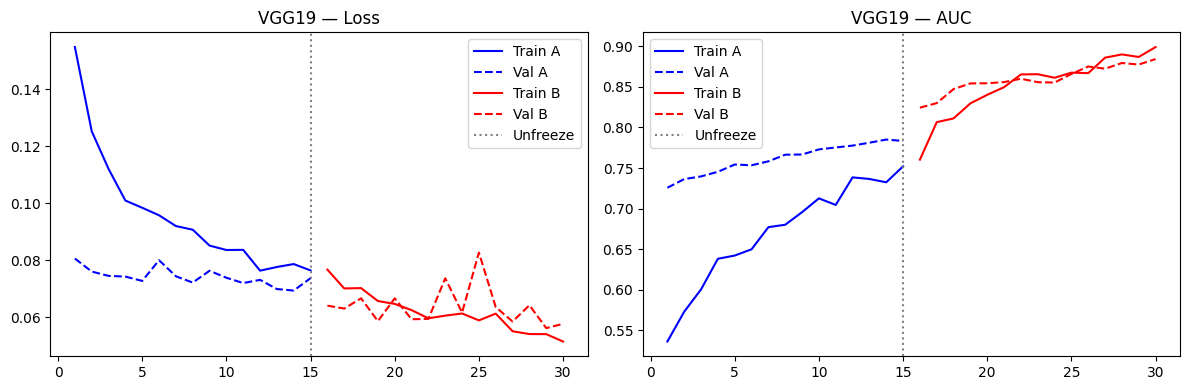

  Curves saved → results/plots/VGG19_curves.png
{'model': 'vgg19', 'AUC': 0.8844, 'PR_AUC': 0.8806, 'Sensitivity': 0.7422, 'Specificity': 0.903, 'F1_pos': 0.795, 'Precision': 0.8559, 'Accuracy': 0.8328, 'Threshold': 0.4903}


In [6]:
# Cell 5 — VGG19
print("="*50)
print("VGG19")
print("="*50)

model_vgg, base_vgg = build_model(VGG19)

# Phase A — frozen base
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_vgg = model_vgg.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_A, callbacks=get_callbacks('vgg19')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_vgg)
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_vgg = model_vgg.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_B, callbacks=get_callbacks('vgg19')
)

save_predictions(model_vgg, val_gen, 'vgg19')
plot_history(hist_a_vgg, hist_b_vgg, 'VGG19')
print(score_model('vgg19'))

ResNet50
Phase A — frozen base (15 epochs)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4251 - auc: 0.4210 - loss: 0.3654

37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 392ms/step - accuracy: 0.4918 - auc: 0.4885 - loss: 0.2908 - val_accuracy: 0.4369 - val_auc: 0.6529 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.5265 - auc: 0.5106 - loss: 0.2724

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 335ms/step - accuracy: 0.5168 - auc: 0.5195 - loss: 0.2646 - val_accuracy: 0.6485 - val_auc: 0.6655 - val_loss: 0.0827 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.4877 - auc: 0.4951 - loss: 0.2461

37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 338ms/step - accuracy: 0.5073 - auc: 0.5174 - loss: 0.2423 - val_accuracy: 0.5256 - val_auc: 0.6665 - val_loss: 0.0832 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5122 - auc: 0.5199 - loss: 0.2122

37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 341ms/step - accuracy: 0.5107 - auc: 0.5040 - loss: 0.2224 - val_accuracy: 0.5666 - val_auc: 0.6759 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 338ms/step - accuracy: 0.4953 - auc: 0.4854 - loss: 0.2236 - val_accuracy: 0.5119 - val_auc: 0.6686 - val_loss: 0.0833 - learning_rate: 0.0010
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 342ms/step - accuracy: 0.5047 - auc: 0.5070 - loss: 0.1898 - val_accuracy: 0.4369 - val_auc: 0.6681 - val_loss: 0.0858 - learning_rate: 0.0010
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5165 - auc: 0.5371 - loss: 0.1754

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 785ms/step - accuracy: 0.6466 - auc: 0.6961 - loss: 0.1058 - val_accuracy: 0.7167 - val_auc: 0.7607 - val_loss: 0.0785 - learning_rate: 1.0000e-05
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.6349 - auc: 0.6862 - loss: 0.1108

37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 782ms/step - accuracy: 0.6621 - auc: 0.7035 - loss: 0.1072 - val_accuracy: 0.5973 - val_auc: 0.7771 - val_loss: 0.0890 - learning_rate: 1.0000e-05
Epoch 9/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 774ms/step - accuracy: 0.6543 - auc: 0.7148 - loss: 0.1037 - val_accuracy: 0.5290 - val_auc: 0.7563 - val_loss: 0.1385 - learning_rate: 1.0000e-05
Epoch 10/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 776ms/step - accuracy: 0.6793 - auc: 0.7252 - loss: 0.1008 - val_accuracy: 0.6997 - val_auc: 0.7634 - val_loss: 0.0778 - learning_rate: 1.0000e-05
Epoch 11/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.6877 - auc: 0.7489 - loss: 0.0988

37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 796ms/step - accuracy: 0.6836 - auc: 0.7487 - loss: 0.0969 - val_accuracy: 0.6485 - val_auc: 0.8060 - val_loss: 0.1018 - learning_rate: 1.0000e-05
Epoch 12/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.6490 - auc: 0.7215 - loss: 0.1031

37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 807ms/step - accuracy: 0.6750 - auc: 0.7335 - loss: 0.1023 - val_accuracy: 0.6177 - val_auc: 0.8085 - val_loss: 0.1075 - learning_rate: 1.0000e-05
Epoch 13/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.6531 - auc: 0.7143 - loss: 0.1117

37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 817ms/step - accuracy: 0.6500 - auc: 0.7003 - loss: 0.1143 - val_accuracy: 0.6655 - val_auc: 0.8154 - val_loss: 0.0900 - learning_rate: 1.0000e-05
Epoch 14/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 811ms/step - accuracy: 0.6784 - auc: 0.7381 - loss: 0.1039 - val_accuracy: 0.6314 - val_auc: 0.8116 - val_loss: 0.1330 - learning_rate: 1.0000e-05
Epoch 15/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 847ms/step - accuracy: 0.6879 - auc: 0.7543 - loss: 0.0986 - val_accuracy: 0.7133 - val_auc: 0.8040 - val_loss: 0.0856 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 13.
  Predictions saved → results/predictions/resnet50.csv


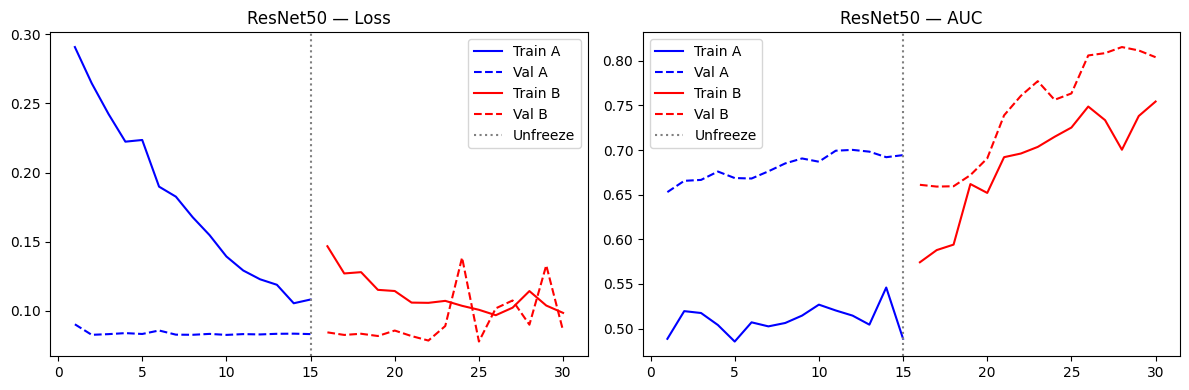

  Curves saved → results/plots/ResNet50_curves.png
{'model': 'resnet50', 'AUC': 0.8158, 'PR_AUC': 0.8354, 'Sensitivity': 0.5938, 'Specificity': 0.9394, 'F1_pos': 0.7103, 'Precision': 0.8837, 'Accuracy': 0.7884, 'Threshold': 0.7842}


In [7]:
# Cell 6 — ResNet50
print("="*50)
print("ResNet50")
print("="*50)

model_res, base_res = build_model(ResNet50)

# Phase A — frozen base
model_res.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_res = model_res.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_A, callbacks=get_callbacks('resnet50')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_res)
model_res.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_res = model_res.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_B, callbacks=get_callbacks('resnet50')
)

save_predictions(model_res, val_gen, 'resnet50')
plot_history(hist_a_res, hist_b_res, 'ResNet50')
print(score_model('resnet50'))

DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Phase A — frozen base (15 epochs)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5652 - auc: 0.5480 - loss: 0.3816

37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 556ms/step - accuracy: 0.5649 - auc: 0.5701 - loss: 0.3709 - val_accuracy: 0.7031 - val_auc: 0.7500 - val_loss: 0.1349 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.6295 - auc: 0.6681 - loss: 0.3355

37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 388ms/step - accuracy: 0.6242 - auc: 0.6715 - loss: 0.3384 - val_accuracy: 0.7031 - val_auc: 0.7832 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6290 - auc: 0.6835 - loss: 0.3239

37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 398ms/step - accuracy: 0.6432 - auc: 0.6929 - loss: 0.3135 - val_accuracy: 0.6997 - val_auc: 0.8154 - val_loss: 0.1126 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6983 - auc: 0.7473 - loss: 0.2469

37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 655ms/step - accuracy: 0.6750 - auc: 0.7346 - loss: 0.2512 - val_accuracy: 0.7338 - val_auc: 0.8322 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 434ms/step - accuracy: 0.6948 - auc: 0.7637 - loss: 0.2281 - val_accuracy: 0.7372 - val_auc: 0.8229 - val_loss: 0.0995 - learning_rate: 0.0010
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.6927 - auc: 0.7636 - loss: 0.2190

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 549ms/step - accuracy: 0.7721 - auc: 0.8457 - loss: 0.1162 - val_accuracy: 0.7952 - val_auc: 0.8961 - val_loss: 0.0647 - learning_rate: 1.0000e-05
Epoch 11/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.7723 - auc: 0.8513 - loss: 0.1049

37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 572ms/step - accuracy: 0.7635 - auc: 0.8362 - loss: 0.1139 - val_accuracy: 0.7918 - val_auc: 0.8969 - val_loss: 0.0614 - learning_rate: 1.0000e-05
Epoch 12/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.7408 - auc: 0.8394 - loss: 0.1121 

37/37 ━━━━━━━━━━━━━━━━━━━━ 1048s 29s/step - accuracy: 0.7661 - auc: 0.8495 - loss: 0.1065 - val_accuracy: 0.7884 - val_auc: 0.8990 - val_loss: 0.0615 - learning_rate: 1.0000e-05
Epoch 13/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 656ms/step - accuracy: 0.7773 - auc: 0.8476 - loss: 0.1086 - val_accuracy: 0.7918 - val_auc: 0.8985 - val_loss: 0.0613 - learning_rate: 1.0000e-05
Epoch 14/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7880 - auc: 0.8603 - loss: 0.1001

37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 540ms/step - accuracy: 0.7876 - auc: 0.8700 - loss: 0.0917 - val_accuracy: 0.7986 - val_auc: 0.9007 - val_loss: 0.0620 - learning_rate: 1.0000e-05
Epoch 15/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.7939 - auc: 0.8672 - loss: 0.0979

37/37 ━━━━━━━━━━━━━━━━━━━━ 23s 612ms/step - accuracy: 0.7850 - auc: 0.8576 - loss: 0.1013 - val_accuracy: 0.7918 - val_auc: 0.9012 - val_loss: 0.0614 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.
  Predictions saved → results/predictions/densenet121.csv


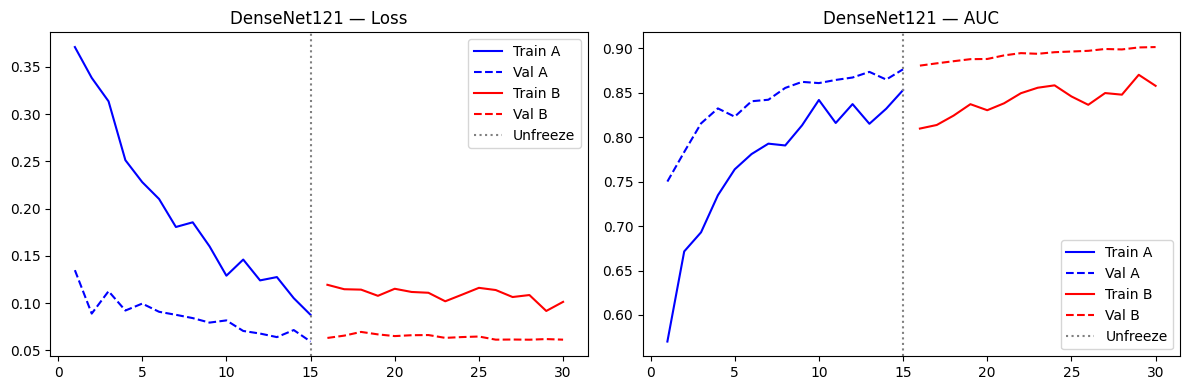

  Curves saved → results/plots/DenseNet121_curves.png
{'model': 'densenet121', 'AUC': 0.9012, 'PR_AUC': 0.8872, 'Sensitivity': 0.9141, 'Specificity': 0.7212, 'F1_pos': 0.8041, 'Precision': 0.7178, 'Accuracy': 0.8055, 'Threshold': 0.3694}


In [8]:
# Cell 7 — DenseNet121
print("="*50)
print("DenseNet121")
print("="*50)

model_dense, base_dense = build_model(DenseNet121)

# Phase A — frozen base
model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_dense = model_dense.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_A, callbacks=get_callbacks('densenet121')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_dense)
model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_dense = model_dense.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_B, callbacks=get_callbacks('densenet121')
)

save_predictions(model_dense, val_gen, 'densenet121')
plot_history(hist_a_dense, hist_b_dense, 'DenseNet121')
print(score_model('densenet121'))

Xception
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Phase A — frozen base (15 epochs)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.5759 - auc: 0.6141 - loss: 0.2222

37/37 ━━━━━━━━━━━━━━━━━━━━ 23s 557ms/step - accuracy: 0.5985 - auc: 0.6374 - loss: 0.2464 - val_accuracy: 0.7133 - val_auc: 0.8024 - val_loss: 0.0787 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6486 - auc: 0.6976 - loss: 0.2412

37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 488ms/step - accuracy: 0.6655 - auc: 0.7215 - loss: 0.2357 - val_accuracy: 0.7611 - val_auc: 0.8281 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.6475 - auc: 0.7085 - loss: 0.2383 - val_accuracy: 0.6143 - val_auc: 0.8230 - val_loss: 0.1750 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7172 - auc: 0.7800 - loss: 0.2040

37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 581ms/step - accuracy: 0.7180 - auc: 0.7772 - loss: 0.1959 - val_accuracy: 0.7440 - val_auc: 0.8377 - val_loss: 0.0833 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.7165 - auc: 0.7770 - loss: 0.1892

37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 775ms/step - accuracy: 0.7025 - auc: 0.7559 - loss: 0.2055 - val_accuracy: 0.7543 - val_auc: 0.8383 - val_loss: 0.0829 - learning_rate: 0.0010
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6982 - auc: 0.7604 - loss: 0.1760 - val_accuracy: 0.7543 - val_auc: 0.8368 - val_loss: 0.0891 - learning_rate: 0.0010
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7008 - auc: 0.7688 - loss: 0.1716 - val_accuracy: 0.7645 - val_auc: 0.8344 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.7191 - auc: 0.7704 - loss: 0.1622

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7799 - auc: 0.8568 - loss: 0.0762 - val_accuracy: 0.8089 - val_auc: 0.8946 - val_loss: 0.0600 - learning_rate: 1.0000e-05
Epoch 11/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7945 - auc: 0.8846 - loss: 0.0633 - val_accuracy: 0.8020 - val_auc: 0.8913 - val_loss: 0.0582 - learning_rate: 1.0000e-05
Epoch 12/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7839 - auc: 0.8727 - loss: 0.0692

37/37 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7850 - auc: 0.8739 - loss: 0.0678 - val_accuracy: 0.8089 - val_auc: 0.8984 - val_loss: 0.0595 - learning_rate: 1.0000e-05
Epoch 13/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7962 - auc: 0.8747 - loss: 0.0702

37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.7885 - auc: 0.8682 - loss: 0.0737 - val_accuracy: 0.7986 - val_auc: 0.9000 - val_loss: 0.0574 - learning_rate: 1.0000e-05
Epoch 14/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7911 - auc: 0.8717 - loss: 0.0725

37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.7979 - auc: 0.8679 - loss: 0.0727 - val_accuracy: 0.8055 - val_auc: 0.9002 - val_loss: 0.0570 - learning_rate: 1.0000e-05
Epoch 15/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8010 - auc: 0.8728 - loss: 0.0734

37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8074 - auc: 0.8814 - loss: 0.0686 - val_accuracy: 0.8089 - val_auc: 0.9035 - val_loss: 0.0558 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.
  Predictions saved → results/predictions/xception.csv


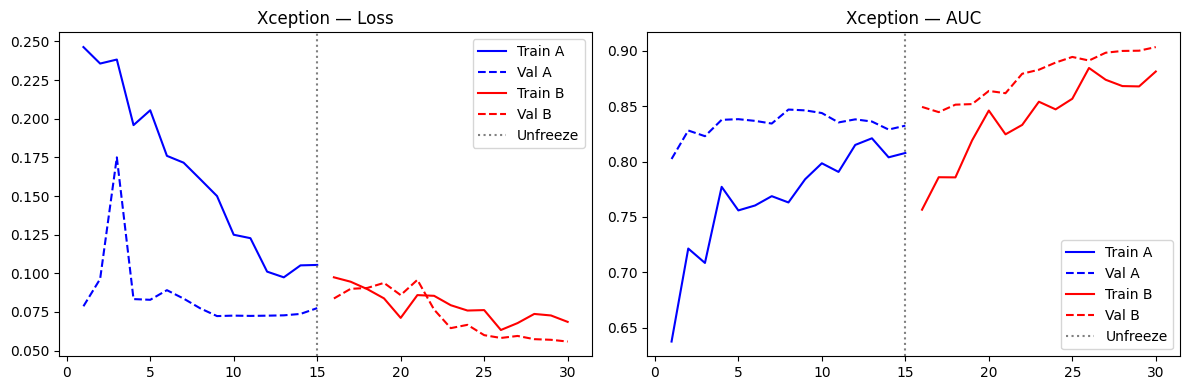

  Curves saved → results/plots/Xception_curves.png
{'model': 'xception', 'AUC': 0.9037, 'PR_AUC': 0.885, 'Sensitivity': 0.8828, 'Specificity': 0.7515, 'F1_pos': 0.8014, 'Precision': 0.7338, 'Accuracy': 0.8089, 'Threshold': 0.4749}


In [9]:
# Cell 8 — Xception
print("="*50)
print("Xception")
print("="*50)

model_xcep, base_xcep = build_model(Xception)

# Phase A — frozen base
model_xcep.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_xcep = model_xcep.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_A, callbacks=get_callbacks('xception')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_xcep)
model_xcep.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_xcep = model_xcep.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_B, callbacks=get_callbacks('xception')
)

save_predictions(model_xcep, val_gen, 'xception')
plot_history(hist_a_xcep, hist_b_xcep, 'Xception')
print(score_model('xception'))

EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Phase A — frozen base (15 epochs)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5005 - auc: 0.4865 - loss: 0.1215

37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 353ms/step - accuracy: 0.5176 - auc: 0.5110 - loss: 0.1371 - val_accuracy: 0.4369 - val_auc: 0.5239 - val_loss: 0.0858 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4765 - auc: 0.4713 - loss: 0.1650

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.4918 - auc: 0.4747 - loss: 0.1650 - val_accuracy: 0.4369 - val_auc: 0.6413 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 227ms/step - accuracy: 0.5039 - auc: 0.5205 - loss: 0.1468 - val_accuracy: 0.5631 - val_auc: 0.5024 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.5047 - auc: 0.4932 - loss: 0.1458 - val_accuracy: 0.4369 - val_auc: 0.5000 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5028 - auc: 0.5048 - loss: 0.1341
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - accuracy: 0.5004 - auc: 0.5024 - loss: 0.1338 - val_accuracy: 0.4369 - val_auc: 0.5000 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.4875 - auc: 0.4933 - loss: 0.1309 - val_accu

37/37 ━━━━━━━━━━━━━━━━━━━━ 34s 586ms/step - accuracy: 0.5211 - auc: 0.5339 - loss: 0.1160 - val_accuracy: 0.4369 - val_auc: 0.5930 - val_loss: 0.0863 - learning_rate: 1.0000e-05
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5055 - auc: 0.4942 - loss: 0.1144

37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 411ms/step - accuracy: 0.5099 - auc: 0.5113 - loss: 0.1111 - val_accuracy: 0.4369 - val_auc: 0.6317 - val_loss: 0.0866 - learning_rate: 1.0000e-05
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5392 - auc: 0.5378 - loss: 0.1041

37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 477ms/step - accuracy: 0.5168 - auc: 0.5143 - loss: 0.1048 - val_accuracy: 0.4369 - val_auc: 0.6356 - val_loss: 0.0877 - learning_rate: 1.0000e-05
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 490ms/step - accuracy: 0.5142 - auc: 0.5082 - loss: 0.1047 - val_accuracy: 0.4369 - val_auc: 0.5362 - val_loss: 0.0873 - learning_rate: 1.0000e-05
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 509ms/step - accuracy: 0.5047 - auc: 0.5158 - loss: 0.0990 - val_accuracy: 0.4369 - val_auc: 0.6040 - val_loss: 0.0883 - learning_rate: 1.0000e-05
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.5076 - auc: 0.4950 - loss: 0.0992
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 531ms/step - accuracy: 0.4884 - auc: 0.4812 - loss: 0.0988 - val_accuracy: 0.4369 - val_auc: 0.6174 - val_loss: 0.0878 - learning_rate: 1.0000e-05
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 526ms/step - accuracy: 0.4944 - auc: 0.4863 - l

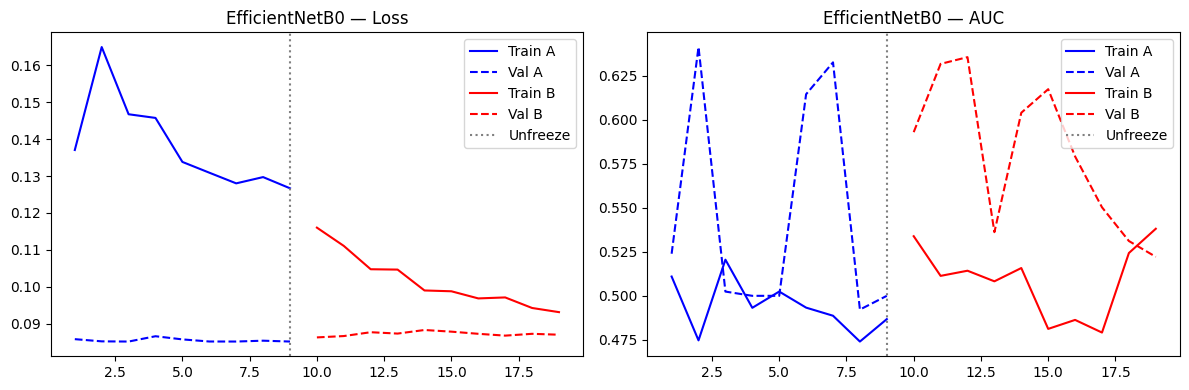

  Curves saved → results/plots/EfficientNetB0_curves.png
{'model': 'efficientnetb0', 'AUC': 0.6048, 'PR_AUC': 0.5914, 'Sensitivity': 0.4062, 'Specificity': 0.8727, 'F1_pos': 0.5174, 'Precision': 0.7123, 'Accuracy': 0.6689, 'Threshold': 0.5427}


In [10]:
# Cell 9 — EfficientNetB0
print("="*50)
print("EfficientNetB0")
print("="*50)

model_eff, base_eff = build_model(EfficientNetB0)

# Phase A — frozen base
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_eff = model_eff.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_A, callbacks=get_callbacks('efficientnetb0')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_eff)
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_eff = model_eff.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_B, callbacks=get_callbacks('efficientnetb0')
)

save_predictions(model_eff, val_gen, 'efficientnetb0')
plot_history(hist_a_eff, hist_b_eff, 'EfficientNetB0')
print(score_model('efficientnetb0'))

EfficientNetB0 REDO — correct preprocessing
Found 1163 images belonging to 2 classes.
Found 293 images belonging to 2 classes.
Phase A — frozen base (15 epochs)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6375 - auc: 0.6830 - loss: 0.1561

37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.6776 - auc: 0.7406 - loss: 0.1503 - val_accuracy: 0.7577 - val_auc: 0.8399 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7008 - auc: 0.7605 - loss: 0.1682

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.7120 - auc: 0.7887 - loss: 0.1479 - val_accuracy: 0.7816 - val_auc: 0.8620 - val_loss: 0.0716 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7636 - auc: 0.8486 - loss: 0.1139

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.7670 - auc: 0.8554 - loss: 0.1122 - val_accuracy: 0.8020 - val_auc: 0.8682 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7386 - auc: 0.8339 - loss: 0.1350

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step - accuracy: 0.7558 - auc: 0.8445 - loss: 0.1237 - val_accuracy: 0.6997 - val_auc: 0.8736 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7833 - auc: 0.8582 - loss: 0.1167

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - accuracy: 0.7825 - auc: 0.8669 - loss: 0.0963 - val_accuracy: 0.7747 - val_auc: 0.8857 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 9/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7573 - auc: 0.8432 - loss: 0.1121

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.7713 - auc: 0.8500 - loss: 0.1111 - val_accuracy: 0.7065 - val_auc: 0.8876 - val_loss: 0.0981 - learning_rate: 0.0010
Epoch 10/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.7954 - auc: 0.8806 - loss: 0.0876 - val_accuracy: 0.7645 - val_auc: 0.8855 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 11/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.7868 - auc: 0.8759 - loss: 0.0885 - val_accuracy: 0.7611 - val_auc: 0.8861 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 12/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7896 - auc: 0.8676 - loss: 0.0849

37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.7756 - auc: 0.8597 - loss: 0.0915 - val_accuracy: 0.7509 - val_auc: 0.8912 - val_loss: 0.0690 - learning_rate: 0.0010
Epoch 13/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.7859 - auc: 0.8670 - loss: 0.0807 - val_accuracy: 0.7747 - val_auc: 0.8909 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 14/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7846 - auc: 0.8602 - loss: 0.0866

37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 304ms/step - accuracy: 0.7868 - auc: 0.8676 - loss: 0.0800 - val_accuracy: 0.7440 - val_auc: 0.8948 - val_loss: 0.0657 - learning_rate: 0.0010
Epoch 15/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 311ms/step - accuracy: 0.8031 - auc: 0.8872 - loss: 0.0696 - val_accuracy: 0.7372 - val_auc: 0.8928 - val_loss: 0.0709 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 14.

Phase B — unfreezing top 25%
  Unfroze last 60 of 238 layers (25.2%)
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7037 - auc: 0.8372 - loss: 0.0865

37/37 ━━━━━━━━━━━━━━━━━━━━ 35s 582ms/step - accuracy: 0.7214 - auc: 0.8512 - loss: 0.0804 - val_accuracy: 0.7713 - val_auc: 0.8920 - val_loss: 0.0695 - learning_rate: 1.0000e-05
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 482ms/step - accuracy: 0.7567 - auc: 0.8689 - loss: 0.0665 - val_accuracy: 0.7782 - val_auc: 0.8845 - val_loss: 0.0719 - learning_rate: 1.0000e-05
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 484ms/step - accuracy: 0.8048 - auc: 0.8891 - loss: 0.0601 - val_accuracy: 0.7679 - val_auc: 0.8808 - val_loss: 0.0720 - learning_rate: 1.0000e-05
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8082 - auc: 0.8896 - loss: 0.0598
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 484ms/step - accuracy: 0.7962 - auc: 0.8838 - loss: 0.0601 - val_accuracy: 0.7713 - val_auc: 0.8824 - val_loss: 0.0708 - learning_rate: 1.0000e-05
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 474ms/step - accuracy: 0.8100 - auc: 0.9012 - l

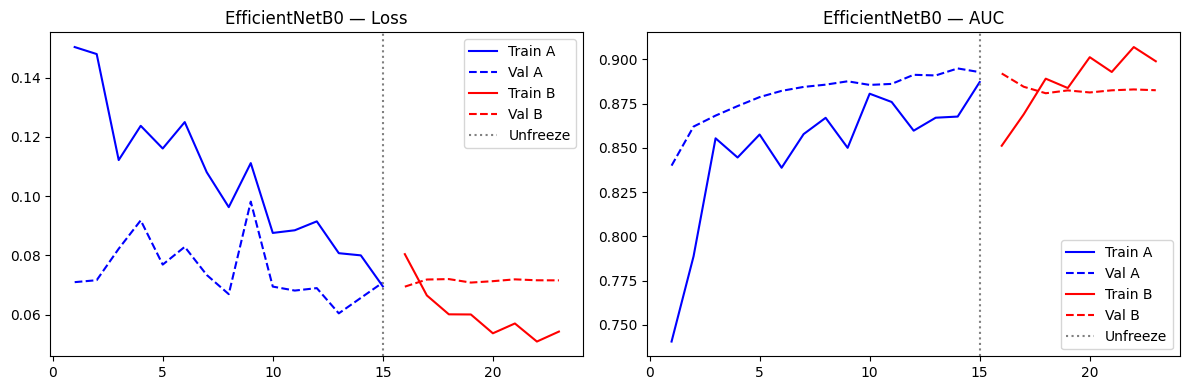

  Curves saved → results/plots/EfficientNetB0_curves.png
{'model': 'efficientnetb0', 'AUC': 0.8924, 'PR_AUC': 0.8776, 'Sensitivity': 0.7656, 'Specificity': 0.8424, 'F1_pos': 0.7778, 'Precision': 0.7903, 'Accuracy': 0.8089, 'Threshold': 0.6652}


In [11]:
# Cell 10 — EfficientNetB0 redo (correct preprocessing — no rescale)
print("="*50)
print("EfficientNetB0 REDO — correct preprocessing")
print("="*50)

# EfficientNet has built-in preprocessing — do NOT rescale 1./255
train_datagen_eff = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    fill_mode='nearest'
)
val_datagen_eff = ImageDataGenerator()  # no rescale

train_gen_eff = train_datagen_eff.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', seed=SEED
)
val_gen_eff = val_datagen_eff.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', seed=SEED, shuffle=False
)

model_eff2, base_eff2 = build_model(EfficientNetB0)

# Phase A — frozen base
model_eff2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Phase A — frozen base (15 epochs)")
hist_a_eff2 = model_eff2.fit(
    train_gen_eff, validation_data=val_gen_eff,
    epochs=EPOCHS_A, callbacks=get_callbacks('efficientnetb0')
)

# Phase B — unfreeze top 25%
print("\nPhase B — unfreezing top 25%")
unfreeze_top_25pct(base_eff2)
model_eff2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
hist_b_eff2 = model_eff2.fit(
    train_gen_eff, validation_data=val_gen_eff,
    epochs=EPOCHS_B, callbacks=get_callbacks('efficientnetb0')
)

save_predictions(model_eff2, val_gen_eff, 'efficientnetb0')
plot_history(hist_a_eff2, hist_b_eff2, 'EfficientNetB0')
print(score_model('efficientnetb0'))